# **Proyek Analisis Data: Bike Sharing Demand Analysis**

# **Menentukan Pertanyaan Bisnis**



*   Pada musim apa transaksi penyewaan sepeda tinggi dan terendah?
*   Pada bulan apa saja transaksi paling tinggi dan paling rendah?



# **Import Semua Packages/Library yang Diigunakan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **Data Wrangling**

## Gathering Data
Tahap mengumpulkan data

In [ ]:
day_path="/content/day.csv"
day_df=pd.read_csv(day_path)

In [ ]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Insight

Untuk bisa mengetahui atau membaca informasi dari dataset yang diinginkan bisa menggunakan kode day_df=pd.read_csv(day_path), selanjutnya buat kode day_df.head() untuk menampilkan 5 informasi dari dataset yang diinginkan.

## Assessing Data

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
print("jumlah duplikat", day_df.duplicated().sum())

jumlah duplikat 0


In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



Insight

*   Tidak terjadi duplikasi data pada dataset day.csv
*   Terjadi kesalahan data type pada kolom dteday, seharusnya data type nya adalah datetime bukan object
*   Tidak terjadi missing value pada dataset day.csv








## Cleaning Data

### Menangani masalah data type dari kolom dteday

pada data set tersebut, seharusnya kolom dteday menggunakan data type datetime atau tanggal dengan format: YYYY-MM-DD bukan menggunakan data type object

In [ ]:
date_time_columns=["dteday"]
for column in date_time_columns:
  day_df[column]=pd.to_datetime(day_df[column])
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

Insight


*   data type pada kolom dteday sudah diganti menjadi datetime
*   setiap kolom dalam dataset sudah menggunakan data type yang sesuai
*   dataset tidak mengalami duplikasi, missing value dan inkonsistensi data







## **Exploratory Data Analysis (EDA)**

### **Explor dataset day.csv**

In [ ]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


### **Jumlah transaksi berdasarkan musim**

In [ ]:
day_df.groupby(by="season").instant.nunique().sort_values(ascending=False)

,instant
season,
3,188
2,184
1,181
4,178


Insight



*   transaksi banyak dilakukan di musim ke tiga, yaitu fall

*   transaksi sedikit ddilakukan di musim ke 4, yaitu winter








### **Jumlah transaksi terbanyak dan terendah berdasarkan tahun**

In [ ]:
day_df.groupby(by="mnth").instant.nunique().sort_values(ascending=False)

,instant
mnth,
1,62
3,62
7,62
5,62
12,62
10,62
8,62
4,60
9,60


Insight



*   bulan dengan transaksi terbanyak ada 7 bulan, karena jumlah transaksinya sama, yaitu ada bulan 1, 3, 7, 5, 12,10, dan 8
*   bulan dengan transaksi terendah ada 1 bulan, yaitu
bulan 2






## **Visualization & Explanatory Analysis**

Pertanyaan 1:Pada musim apa transaksi penyewaan sepeda tinggi?

/tmp/ipython-input-475753683.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-475753683.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


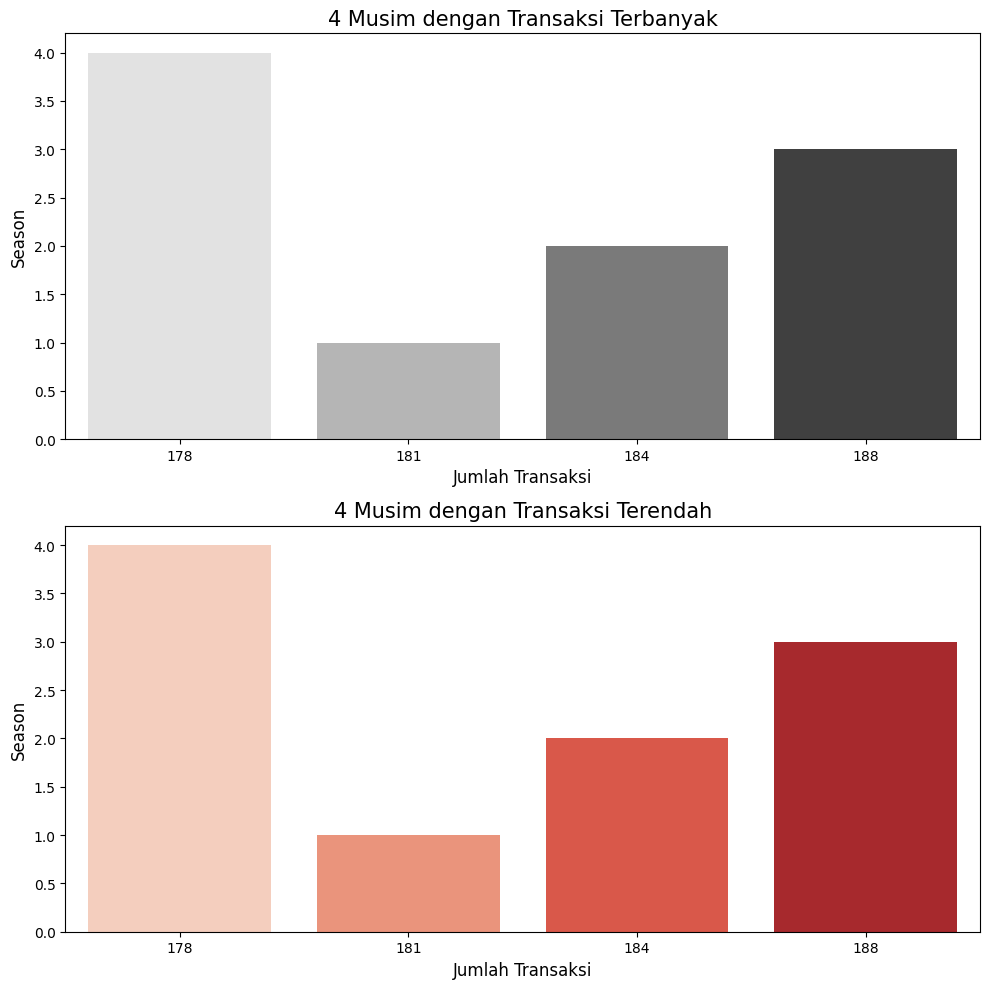

In [ ]:
# Hitung jumlah transaksi per musim
season_df = day_df.groupby("season").size()

# Ambil 4 musim dengan transaksi terbanyak & terendah
top4_season_df = season_df.nlargest(4)
bottom4_season_df = season_df.nsmallest(4)

# Membuat figure
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# Plot 4 musim dengan transaksi terbanyak
sns.barplot(
    x=top4_season_df.values,
    y=top4_season_df.index,
    palette="Grays",
    ax=axes[0]
)
axes[0].set_title("4 Musim dengan Transaksi Terbanyak", fontsize=15)
axes[0].set_xlabel("Jumlah Transaksi", fontsize=12)
axes[0].set_ylabel("Season", fontsize=12)

# Plot 4 musim dengan transaksi terendah
sns.barplot(
    x=bottom4_season_df.values,
    y=bottom4_season_df.index,
    palette="Reds",
    ax=axes[1]
)
axes[1].set_title("4 Musim dengan Transaksi Terendah", fontsize=15)
axes[1].set_xlabel("Jumlah Transaksi", fontsize=12)
axes[1].set_ylabel("Season", fontsize=12)

# Menyesuaikan layout
plt.tight_layout()
plt.show()


Insight


*  musim dengan transaksi terbanyak adalah musim 3
*  musim dengan transaksi terbanyak adalah musim 4



Pertanyaan 2:Pada bulan apa saja transaksi paling tinggi dan paling rendah?

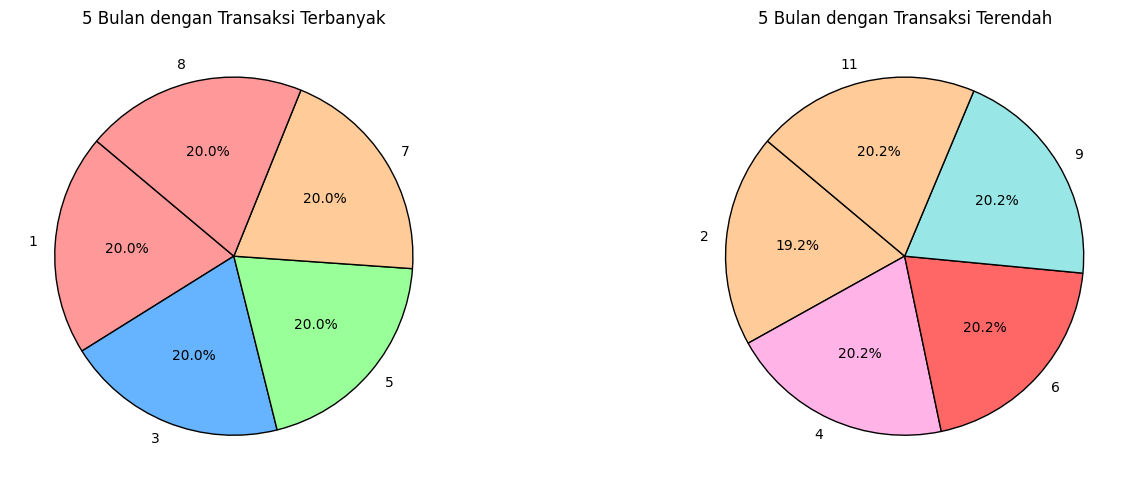

In [ ]:
# Menghitung jumlah transaksi per tahun
mnth_count = day_df.groupby('mnth').size()

# Mengambil 1 tahun dengan transaksi tertinggi
top_5_mnth = mnth_count.nlargest(5)

# Mengambil 1 tahun dengan transaksi terendah
bottom_5_mnth = mnth_count.nsmallest(5)

# Warna untuk pie chart
colors_top = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
colors_bottom = ['#ffcc99', '#ffb3e6', '#ff6666', '#99e6e6']

# Membuat figure dengan dua subplot untuk pie chart
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Pie chart untuk tahun dengan transaksi terbanyak
axes[0].pie(
    top_5_mnth.values,
    labels=top_5_mnth.index,
    autopct='%1.1f%%',
    colors=colors_top,
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title("5 Bulan dengan Transaksi Terbanyak")

# Pie chart untuk tahun dengan transaksi terendah
axes[1].pie(
    bottom_5_mnth.values,
    labels=bottom_5_mnth.index,
    autopct='%1.1f%%',
    colors=colors_bottom,
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title("5 Bulan dengan Transaksi Terendah")

# Menyesuaikan layout agar tidak bertabrakan
plt.tight_layout()
plt.show()


Insight


*  Bulan dengan transaksi paling tinggi adalah bulan 1, 3, 5, 7 dan 8 (Januari, Maret, Mei, Juli, dan Agustus), bulan-bulan ini memiliki jumlah transaksi yang sama sekaligus tertinggi
*   Bulan dengan transaksi paling rendah adalah bulan 2, yaitu Februari



## **Conclusion**



*   Conclusion pertanyaan 1 : berdasarkan musim transaksi paling banyak terjadi pada musim 3 atau musim fall dan terendah terjadi pada musim 4 atau musim winter
*   Conclusion pertanyaan 2: berdasarkan bulan transaksi banyak dilakukan di bulan 1,3,7,5,dan 8 (Januari, Maret, Mei, Juli, dan Agustus) sedangkan terendah terjadi di bulan 2 (Februari)



In [ ]:
day_df.to_csv("day_cleaned.csv", index=False)